In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
from IPython.display import display, Markdown

In [4]:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

In [10]:
df = pd.read_excel("./data_raw/DataSet_V49 (2).xlsx")

print(f"Данные успешно загружены! Размер: {df.shape}")
print(f"Занимаемая память: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Данные успешно загружены! Размер: (17430, 465)
Занимаемая память: 189.51 MB


In [11]:
from models.tabular.MiniModels.BalancedAccuracy.my_library import do_magic

In [15]:
for i in df.columns:
    print(i)

Код пациента
Name
Age
Sex
Наличие в БД
Наличие в файле
STEMI
ЧКВ
Дата STEMI
Вид STEMI
SYNTAX Score
Инфаркт-зависимая артерия
Поражение ствола
Количество пораженных сосудов(Syntax)
Количество пораженных сосудов(Значимость)
TIMI
Инфаркт миокарда в анамнезе (<3)
Инфаркт миокарда в анамнезе (>3)
Инфаркт миокарда со стентированием в анамнезе
ОНМК (иш) в анамнезе
ОНМК (гем) в анамнезе
Стентирование в анамнезе
Тромболизис
Форма ФП
Калий
Дилатация предсердий
ФП b (после чкв)
ФП a (в анамнезе)
ФП при окс (до чкв)
ФП постоянная форма
ФЖ
Пробежки ЖТ
Рецидивирующая ЖТ
MKB
Класс ОСН по Killip
ХСН стадия
ХСН фк
ГБ стадия
ГБ риск
АГ
Стенокардия (ИБ)
Стенокардия форма(ИБ)
Стенокардия ФК (ИБ)
СД
ХБП
ЯБ
МКБ
ЖКБ
ФВ ЛЖ (b)
ФВ ЛЖ
EDV
КДР ЛЖ
КСР ЛЖ
МЖП
ЗСЛЖ
ПСПЖ
СДЛА
Размер правого желудочка
Стеноз аортального клапана (степень)
Недостаточность аортального клапана (степень)
Стеноз митрального клапана (степень)
Недостаточность митрального клапана (степень)
Недостаточность трикуспидального клапана (степень)
НП

In [19]:
df_copy = df[[
    "Смерть",
    "Age",
    "Sex",
    "ЧСС(а)",
    "ДАД(a)"
]]

## 📊 Базовая информация о датасете

### 💾 Информация о типах данных

```
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17430 entries, 0 to 17429
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Смерть  16613 non-null  object 
 1   Age     17406 non-null  float64
 2   Sex     17355 non-null  object 
 3   ЧСС(а)  8247 non-null   float64
 4   ДАД(a)  12150 non-null  object 
dtypes: float64(2), object(3)
memory usage: 681.0+ KB

```

,Column,Type,First Value,Last Value,Unique Values
Смерть,Смерть,object,Нет,Нет,2
Age,Age,float64,78.00,53.00,79
Sex,Sex,object,М,М,2
ЧСС(а),ЧСС(а),float64,nan,nan,93
ДАД(a),ДАД(a),object,70,nan,135


### 📈 Описательная статистика числовых признаков

...

### 🔍 Анализ уникальных значений (первые 10 столбцов)

,unique_count,unique_values,dtype
Смерть,2,"[Нет, Да, nan]",object
Age,79,"[78.0, 80.0, 40.0, 75.0, 61.0, 69.0, 67.0, 49....",float64
Sex,2,"[М, Ж, nan]",object
ЧСС(а),93,"[nan, 65.0, 80.0, 70.0, 72.0, 82.0, 74.0, 75.0...",float64
ДАД(a),135,"[70, 80, 60, 65, 90, nan, 72, 80, 85, 60]",object


## ⚖️ Анализ дисбаланса классов

### Целевая переменная: `Смерть`

,Класс,Количество,Процент
0,0.000000,16038,92.013769
1,1.000000,575,3.298910


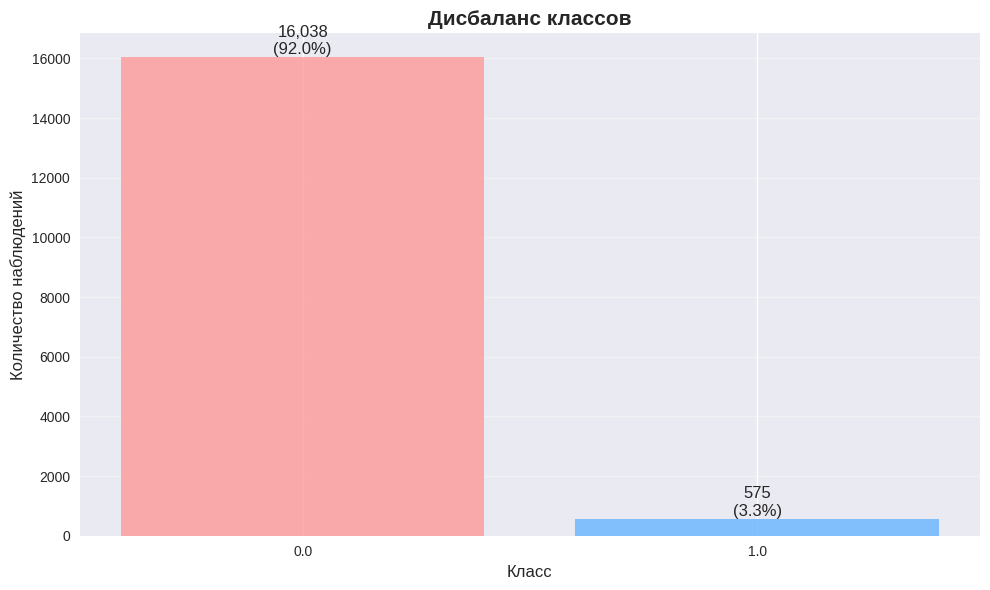

### 📈 Степень дисбаланса: 27.9:1

⚠️ **Сильный дисбаланс!** Требуются специальные методы обработки.

## 🕳️ Анализ пропущенных значений

### 📊 Общая статистика по пропускам:

- Всего столбцов с пропусками: 5 из 5

- Средний процент пропусков: 17.65%

- Максимальный процент пропусков: 52.69%

### 🏆 Топ-20 столбцов с наибольшими пропусками:

,Столбец,Процент пропусков
3,ЧСС(а),52.685026
4,ДАД(a),30.292599
0,Смерть,4.687321
2,Sex,0.430293
1,Age,0.137694


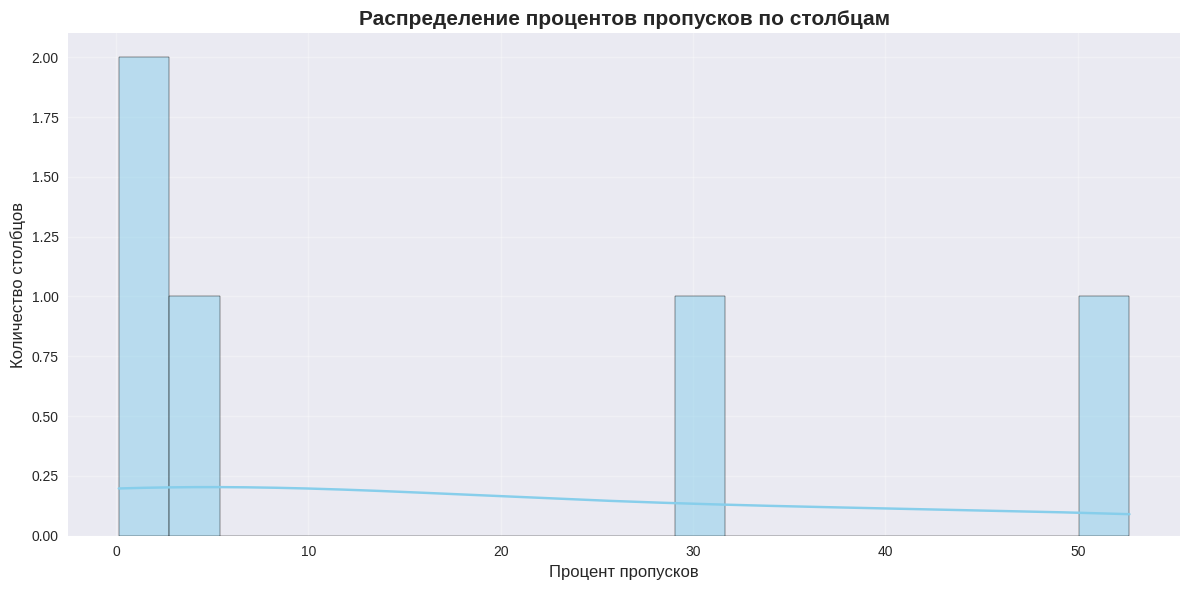

### 🎯 Анализ пропусков в контексте целевой переменной

#### Столбец: `ЧСС(а)`

**Абсолютные значения:**

ЧСС(а),Значение,Пропуск,Всего
Смерть,,,
0.0,8158,7880,16038
1.0,89,486,575
Всего,8247,8366,16613


**Проценты:**

...

## 🏷️ Анализ категориальных признаков на предмет утечек

### Категориальные признаки для анализа: 2

### 🔍 Поиск категориальных признаков с идеальным разделением классов

✅ Не обнаружено категориальных признаков с идеальным разделением классов

## 📐 Анализ мультиколлинеарности признаков

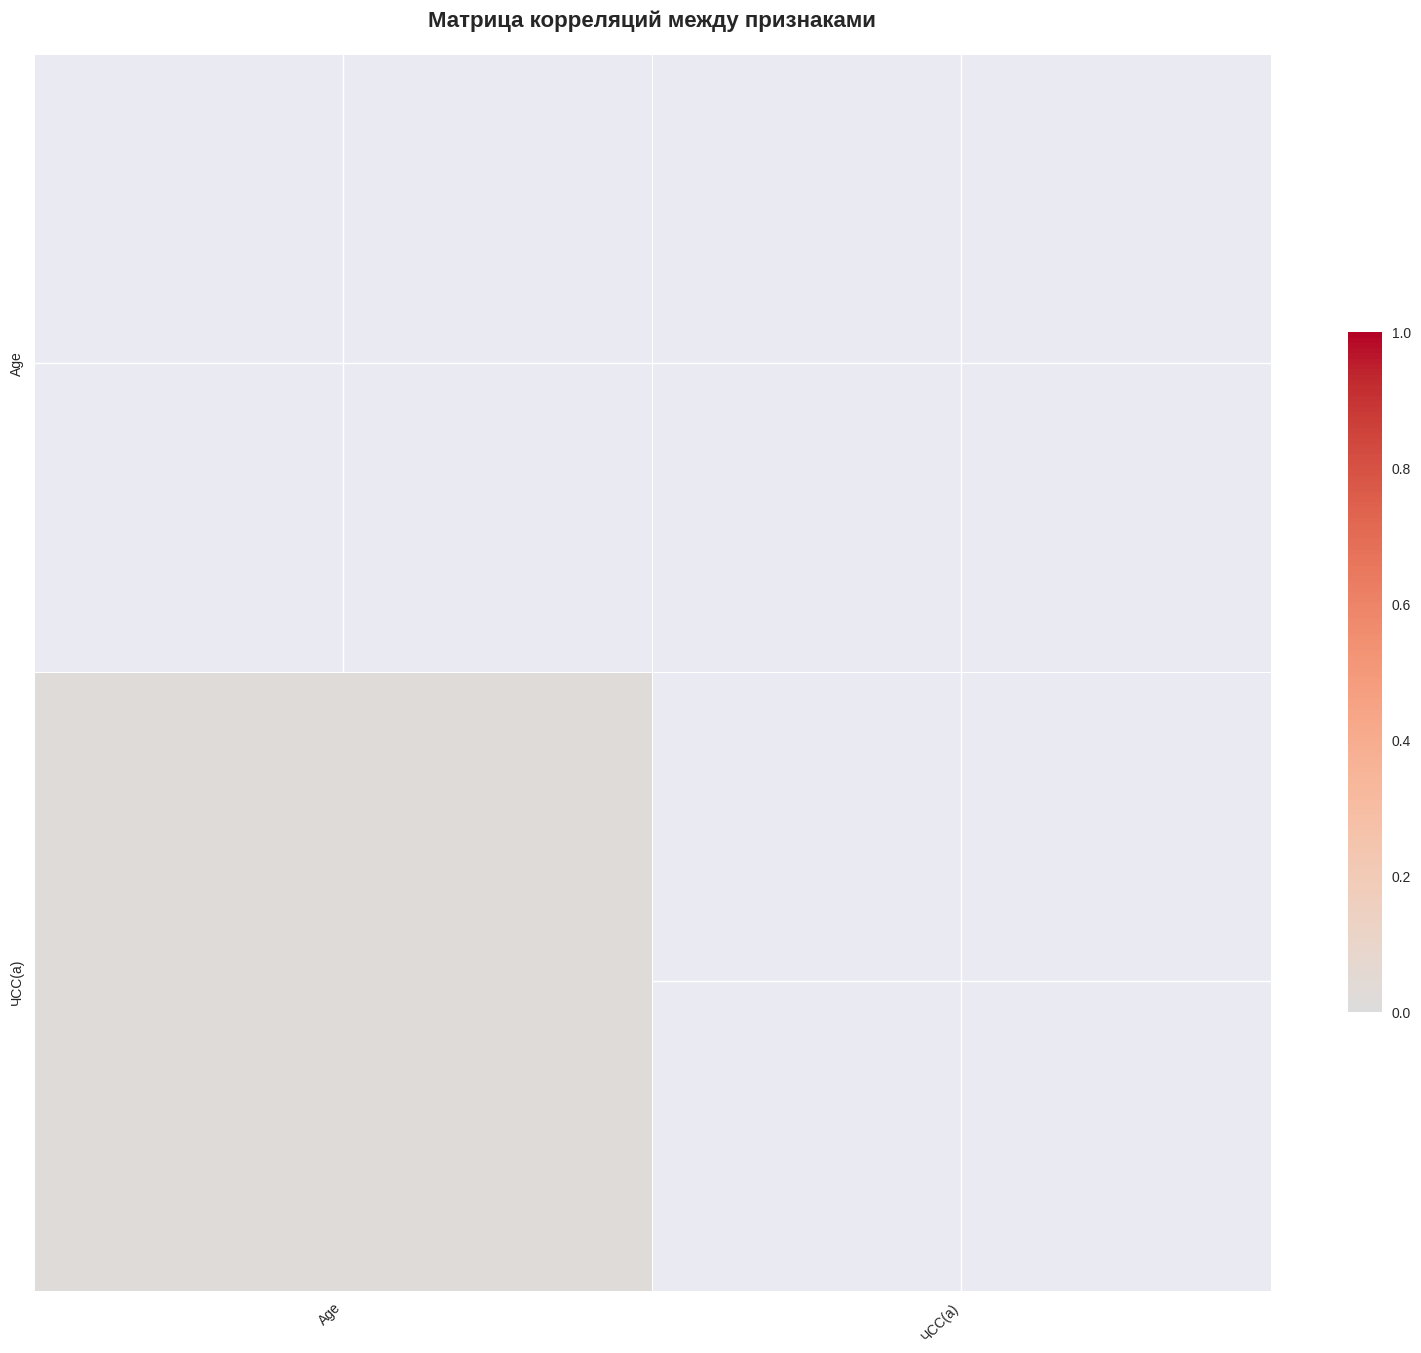

✅ Не обнаружено признаков с экстремально высокой корреляцией между собой

## 📈 Анализ распределений признаков по классам target

### Распределения топ-2 признаков по классам target:

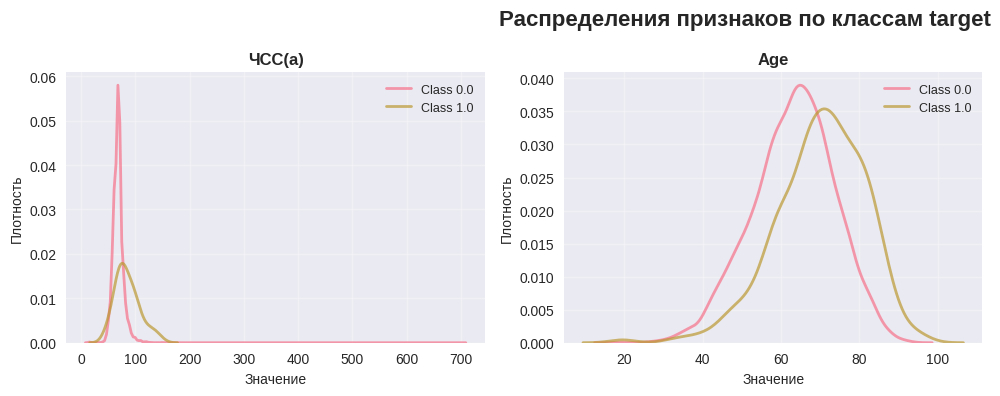

❌ **Данные не загружены!** Выполните сначала ячейки с EDA и загрузкой данных.

### 🗑️ Удалено 817 строк с пропусками в целевой переменной

## ⚖️ Финальный дисбаланс классов:

,Класс,Количество,Процент
0,0,16038,96.538855
1,1,575,3.461145


## 🕳️ Шаг 2: Стратегическая обработка пропусков

...

- False Positive (ложные тревоги): 817

- False Negative (пропущенные смерти) ⚠️: 25

- True Positive (правильные предсказания смерти): 90

❌ **КРИТИЧНО:** Модель пропустила 25 смертельных случаев!

⚠️ **Внимание:** 817 ложных тревог могут привести к ненужным вмешательствам

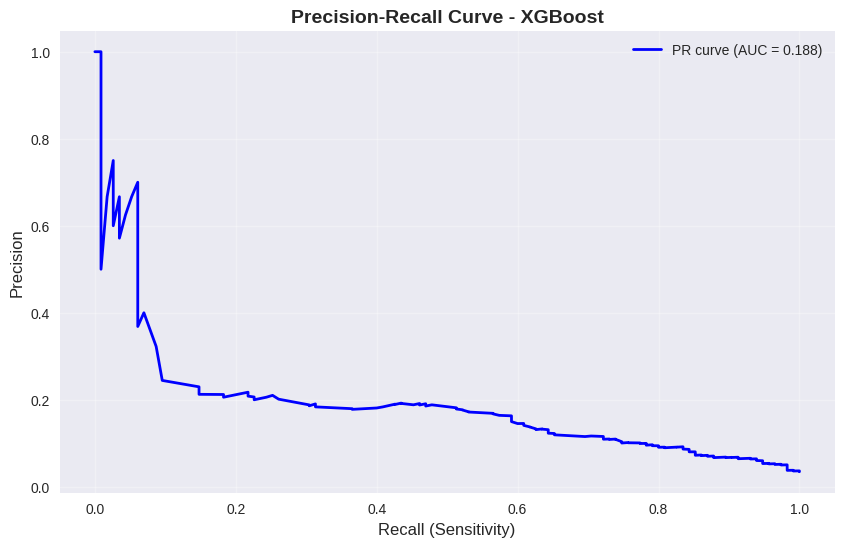

### 🌟 Топ-10 важных признаков (XGBoost):

,Признак,Важность
3,ДАД_a_freq,0.527958
2,ЧСС_а,0.213265
0,Age,0.170898
1,Sex,0.087879


### 🚀 Обучение LightGBM...

✅ **LightGBM обучена за 17.65 секунд**

### 📊 Результаты LightGBM:

...

- False Positive (ложные тревоги): 838

- False Negative (пропущенные смерти) ⚠️: 22

- True Positive (правильные предсказания смерти): 93

❌ **КРИТИЧНО:** Модель пропустила 22 смертельных случаев!

⚠️ **Внимание:** 838 ложных тревог могут привести к ненужным вмешательствам

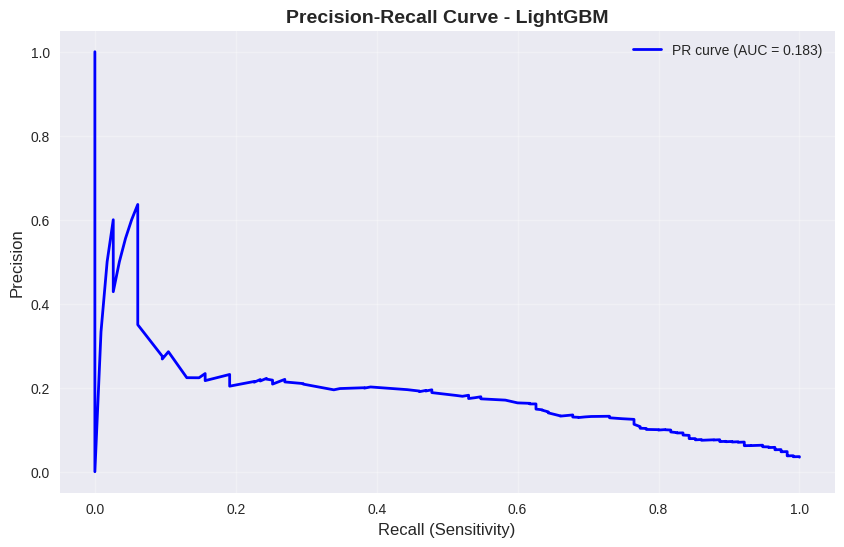

### 🌟 Топ-10 важных признаков (LightGBM):

,Признак,Важность
0,Age,707
2,ЧСС_а,568
3,ДАД_a_freq,522
1,Sex,82


### 🚀 Обучение CatBoost...

✅ **CatBoost обучена за 0.15 секунд**

### 📊 Результаты CatBoost:

...

- False Positive (ложные тревоги): 887

- False Negative (пропущенные смерти) ⚠️: 19

- True Positive (правильные предсказания смерти): 96

❌ **КРИТИЧНО:** Модель пропустила 19 смертельных случаев!

⚠️ **Внимание:** 887 ложных тревог могут привести к ненужным вмешательствам

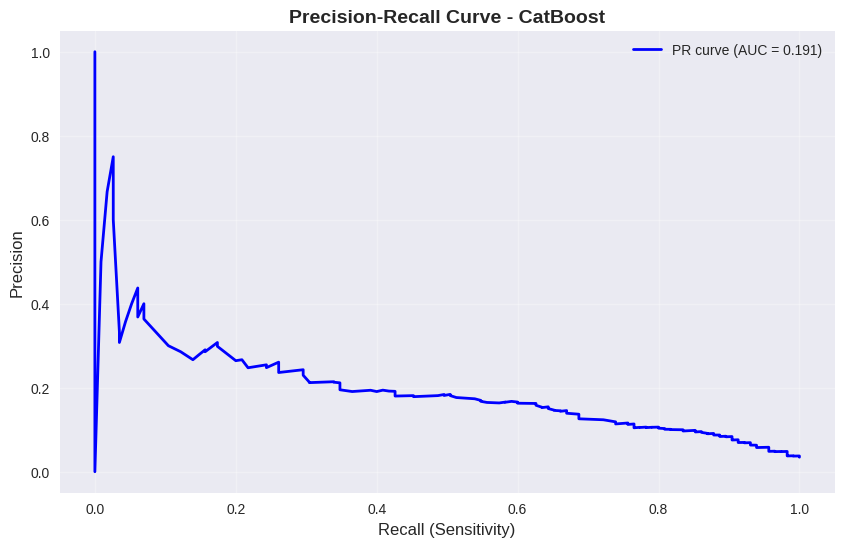

### 🌟 Топ-10 важных признаков (CatBoost):

,Признак,Важность
2,ЧСС_а,33.688518
0,Age,32.567503
3,ДАД_a_freq,27.505017
1,Sex,6.238962


## 📊 Шаг 3: Сравнение моделей и выбор лучшей

### 🏆 Сравнение моделей на тестовом наборе:

,Модель,Recall (Sensitivity),Balanced Accuracy,Precision,F1-score,PR-AUC,ROC-AUC
2,CatBoost,0.835,0.779,0.098,0.175,0.191,0.850
1,LightGBM,0.809,0.774,0.100,0.178,0.183,0.845
0,XGBoost,0.783,0.764,0.099,0.176,0.188,0.836


...

,Predicted 0,Predicted 1
Actual 0 (Выжил),2321,887
Actual 1 (Умер),19,96


### Критические метрики:

- **Recall (Sensitivity) для смерти:** 0.835

- **Количество пропущенных смертей (FN):** 19 из 115

- **Precision для смерти:** 0.098

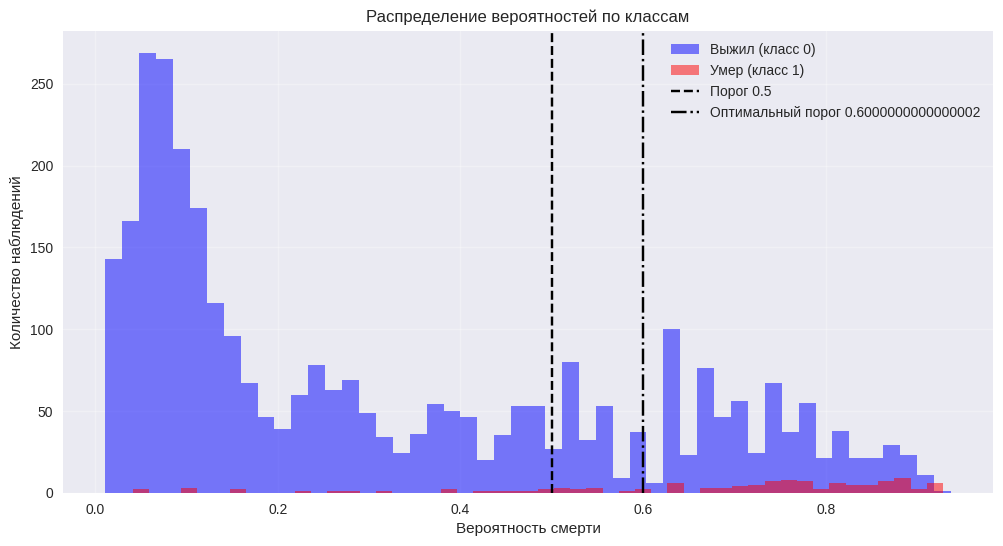

## 🚀 Шаг 1: Гиперпараметрическая оптимизация

### ⚖️ Параметры дисбаланса: scale_pos_weight = 27.9

### 🤖 XGBoost оптимизация

Fitting 3 folds for each of 25 candidates, totalling 75 fits


✅ **XGBoost оптимизирован за 22.26 секунд**

...

**Лучший Balanced Accuracy на validation:** 0.790

## 📊 Шаг 2: Оценка оптимизированных моделей

### 📈 Оценка XGBoost

**Метрики на тестовом наборе:**

,Метрика,Значение
0,Recall,0.895652
1,Balanced Accuracy,0.754715
2,Precision,0.076751
3,F1-score,0.141386
4,ROC-AUC,0.844713
5,PR-AUC,0.193414


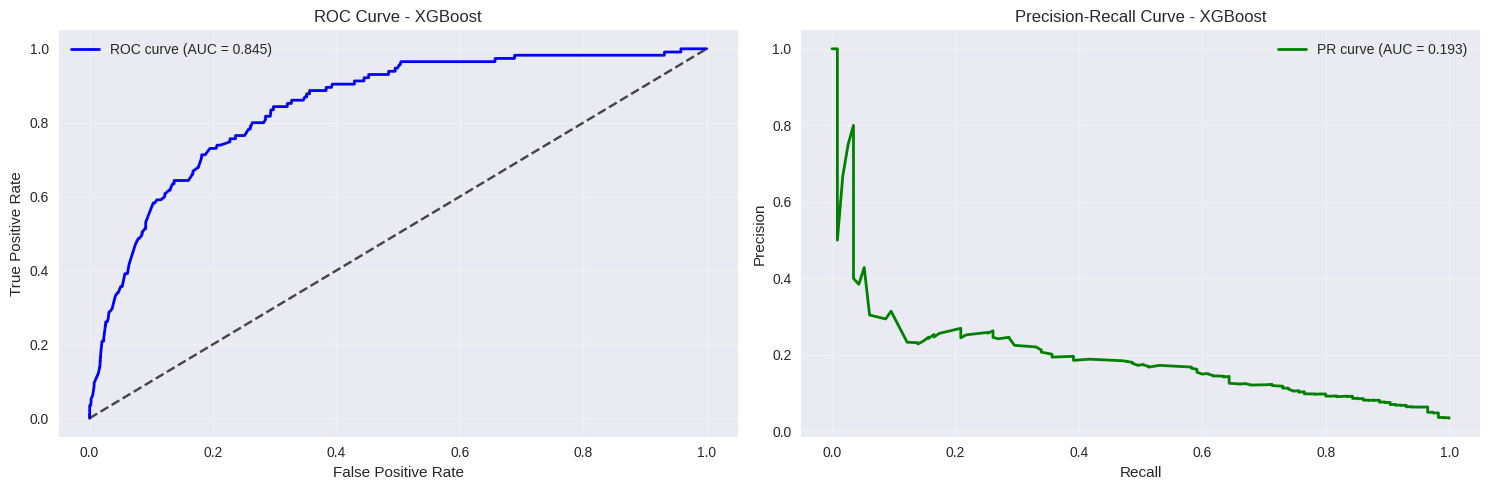

### 📈 Оценка LightGBM

**Метрики на тестовом наборе:**

,Метрика,Значение
0,Recall,0.817391
1,Balanced Accuracy,0.771694
2,Precision,0.096608
3,F1-score,0.172794
4,ROC-AUC,0.848647
5,PR-AUC,0.207311


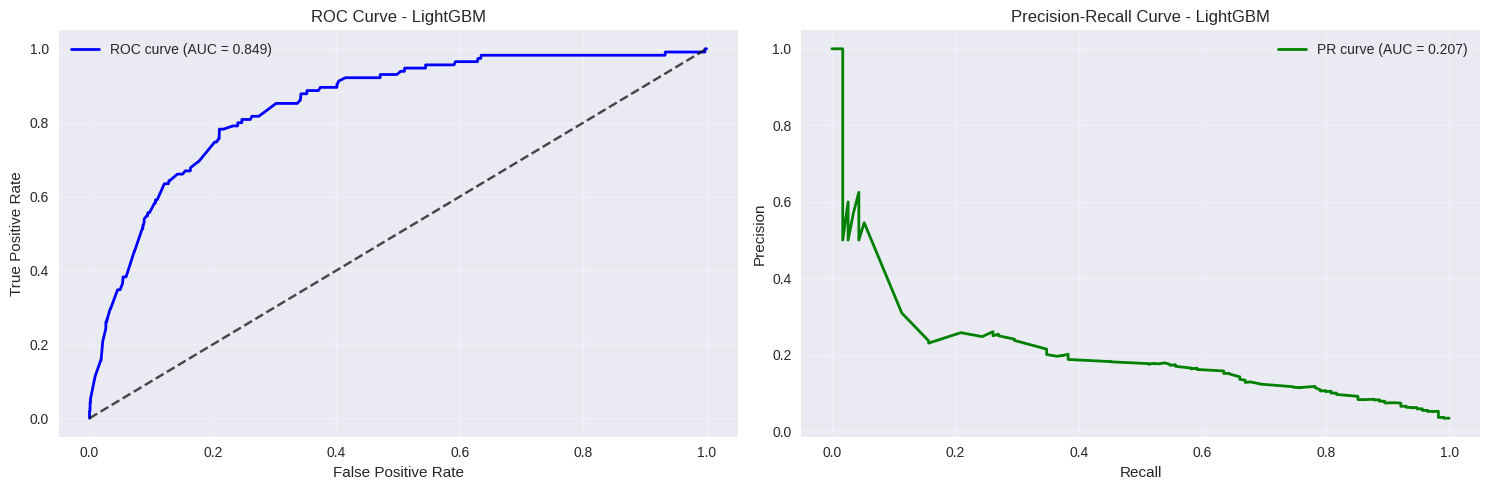

### 📈 Оценка CatBoost

**Метрики на тестовом наборе:**

,Метрика,Значение
0,Recall,0.886957
1,Balanced Accuracy,0.767200
2,Precision,0.082725
3,F1-score,0.151335
4,ROC-AUC,0.848917
5,PR-AUC,0.204609


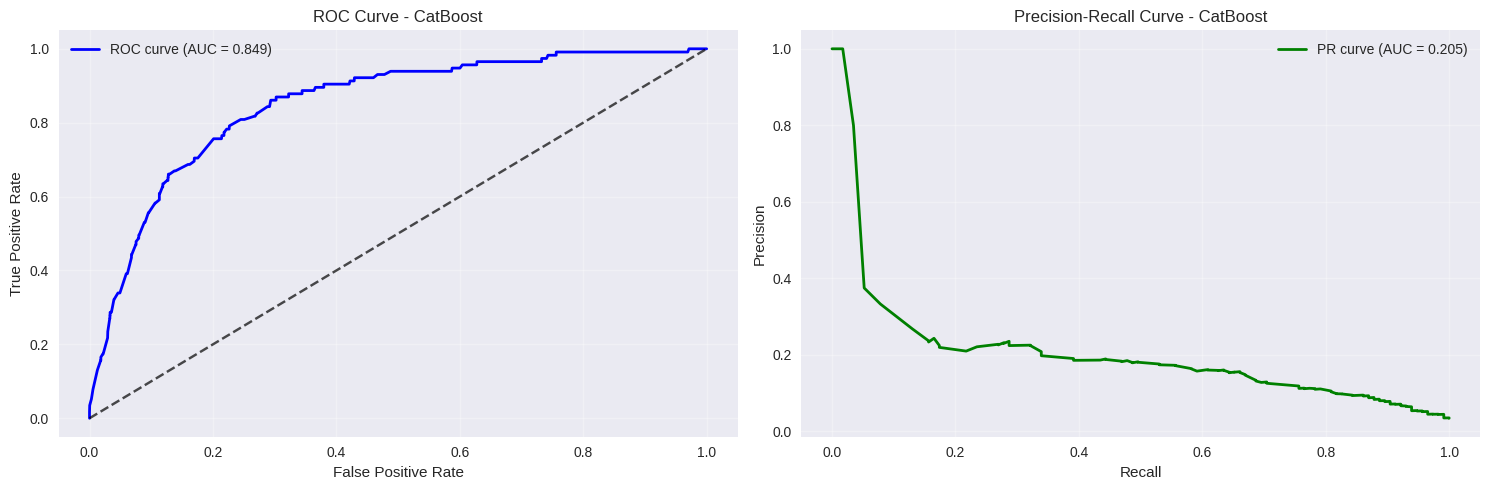

## 🏆 Сравнение оптимизированных моделей:

,Модель,Recall,Balanced Accuracy,Precision,F1-score,ROC-AUC,PR-AUC
1,LightGBM,0.817391,0.771694,0.096608,0.172794,0.848647,0.207311
2,CatBoost,0.886957,0.767200,0.082725,0.151335,0.848917,0.204609
0,XGBoost,0.895652,0.754715,0.076751,0.141386,0.844713,0.193414


## 🎯 Лучшая модель по Balanced Accuracy: **LightGBM**

In [20]:
do_magic(df_copy)